In [11]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots, MCSamples

# ============================================================
# 1. Load samples
# ============================================================

# Load chains data for CPL model
data1 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/cplCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1.txt')
data2 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/cplCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1.txt')
data3 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/cplCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1.txt') 

# Extract weights (column 0)
weights1 = data1[:, 0]
weights2 = data2[:, 0]
weights3 = data3[:, 0]

# Extract cosmological parameters (columns 2-6: Om, Obh2, h, w0, wa)
params1 = data1[:, 2:7]
params2 = data2[:, 2:7]
params3 = data3[:, 2:7]

# Define parameter names and labels
param_names = ['Om', 'Obh2', 'h', 'w0', 'wa']
param_labels = [r'\Omega_m', r'\Omega_b h^2', r'h', r'w_0', r'w_a']

# Create MCSamples objects
samples1 = MCSamples(samples=params1, weights=weights1, names=param_names, labels=param_labels)
samples2 = MCSamples(samples=params2, weights=weights2, names=param_names, labels=param_labels)
samples3 = MCSamples(samples=params3, weights=weights3, names=param_names, labels=param_labels)

samples_list = [samples1, samples2, samples3]

labels = [
    "PLK18+DESIDR2+PantheonPlus",
    "PLK18+DESIDR2+Union3",
    "PLK18+DESIDR2+DESY5"
]

Removed no burn in
Removed no burn in
Removed no burn in


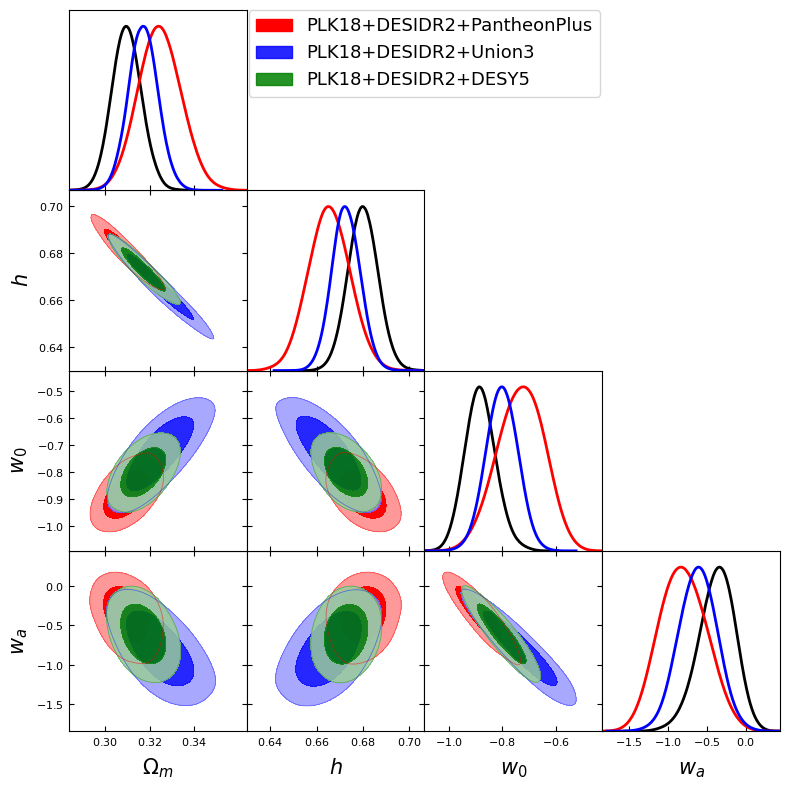

In [35]:
# ============================================================
# 2. Triangle plot
# ============================================================

params = ['Om', 'h', 'w0', 'wa']

g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 16
g.settings.axes_labelsize  = 18
g.settings.lab_fontsize   = 18

g.triangle_plot(
    samples_list,
    params,
    filled=True,
    legend_labels=labels,
    contour_colors=["red", "blue", "green"],
    line_args=[
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2}
    ]
)

plt.savefig("combined_cpl_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
import glob

# Adjust these paths to your actual chain root names
chain_roots = {
    "PLK18+DESIDR2+PantheonPlus": "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/cplCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1",
    "PLK18+DESIDR2+Union3":       "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/cplCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1",
    "PLK18+DESIDR2+DESY5":        "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/cplCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1",
}

def get_chi2_min_from_files(chain_root):
    files = sorted(glob.glob(chain_root + "_*.txt"))
    if not files:
        # try without numbering
        files = [chain_root + ".txt"]
    print(f"  Found {len(files)} chain file(s): {files}")
    
    all_loglikes = []
    for f in files:
        raw = np.loadtxt(f)
        all_loglikes.append(raw[:, 1])   # column 1 = -loglike
    
    combined = np.concatenate(all_loglikes)
    return 2.0 * np.min(combined)

# ============================================================
results = []
for label in labels:
    print(f"\n{label}")
    chi2_min = get_chi2_min_from_files(chain_roots[label])
    N = N_values[label]
    AIC = chi2_min + 2 * k_cpl
    BIC = chi2_min + k_cpl * np.log(N)
    results.append((label, chi2_min, AIC, BIC))
    print(f"chi2_min = {chi2_min:.3f}")
    print(f"AIC      = {AIC:.3f}")
    print(f"BIC      = {BIC:.3f}")


PLK18+DESIDR2+PantheonPlus
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/cplCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1.txt']
chi2_min = 1411.746
AIC      = 1419.746
BIC      = 1441.532

PLK18+DESIDR2+Union3
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/cplCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1.txt']
chi2_min = 29.059
AIC      = 37.059
BIC      = 59.658

PLK18+DESIDR2+DESY5
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/cplCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1.txt']
chi2_min = 1646.140
AIC      = 1654.140
BIC      = 1676.214


/tmp/ipykernel_1394697/3436339146.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


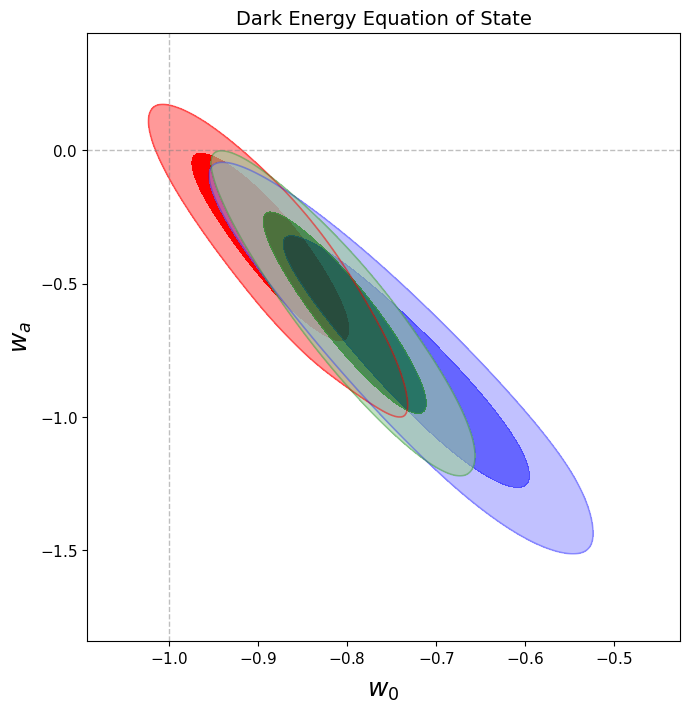

In [36]:
# Create w0 vs wa plot
g2 = plots.get_subplot_plotter(width_inch=7)
g2.settings.figure_legend_frame = True
g2.settings.alpha_filled_add = 0.6

g2.settings.legend_fontsize = 16
g2.settings.axes_labelsize  = 18
g2.settings.lab_fontsize   = 18

g2.plot_2d(samples_list, 
           'w0', 'wa',
           filled=True,
           colors=["red", "blue", "green"],
           legend_labels=labels)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.axvline(x=-1, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.title('Dark Energy Equation of State', fontsize=14)
plt.tight_layout()
plt.savefig("cpl_w0wa.pdf", dpi=900, bbox_inches='tight')
plt.show()

In [37]:
# ---- Text file ----
with open("cpl_AIC_BIC.txt", "w") as f:
    f.write("Dataset\tchi2_min\tAIC\tBIC\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label}\t{chi2:.3f}\t{aic:.3f}\t{bic:.3f}\n")

# ---- LaTeX table ----
with open("cpl_AIC_BIC.tex", "w") as f:
    f.write(r"\begin{tabular}{lccc}" + "\n")
    f.write(r"\hline" + "\n")
    f.write(r"Dataset & $\chi^2_{\min}$ & AIC & BIC \\" + "\n")
    f.write(r"\hline" + "\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label} & {chi2:.2f} & {aic:.2f} & {bic:.2f} \\\\\n")
    f.write(r"\hline" + "\n")
    f.write(r"\end{tabular}" + "\n")

# ============================================================
# 7. Print selected parameter constraints
# ============================================================
'Om', 'h', 'w0', 'wa'
for s, l in zip(samples_list, labels):
    print(f"\nParameter constraints for {l}:")
    print(s.getInlineLatex('Om', limit=1))
    print(s.getInlineLatex('h', limit=1))
    print(s.getInlineLatex('w0', limit=1))
    print(s.getInlineLatex('wa', limit=1))


Parameter constraints for PLK18+DESIDR2+PantheonPlus:
\Omega_m = 0.3096\pm 0.0067
h = 0.6800\pm 0.0065
w_0 = -0.882^{+0.054}_{-0.061}
w_a = -0.37^{+0.25}_{-0.21}

Parameter constraints for PLK18+DESIDR2+Union3:
\Omega_m = 0.3244\pm 0.0097
h = 0.6655\pm 0.0091
w_0 = -0.731^{+0.094}_{-0.085}
w_a = -0.80\pm 0.30

Parameter constraints for PLK18+DESIDR2+DESY5:
\Omega_m = 0.3170\pm 0.0066
h = 0.6727\pm 0.0061
w_0 = -0.802\pm 0.060
w_a = -0.61\pm 0.25


/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_set1_PP_CMB_DESI.1.txt
Removed 0.3 as burn in
/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_set2_DESY5_CMB_DESI.1.txt
Removed 0.3 as burn in
/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_set3_CMB_DESI.1.txt
Removed 0.3 as burn in


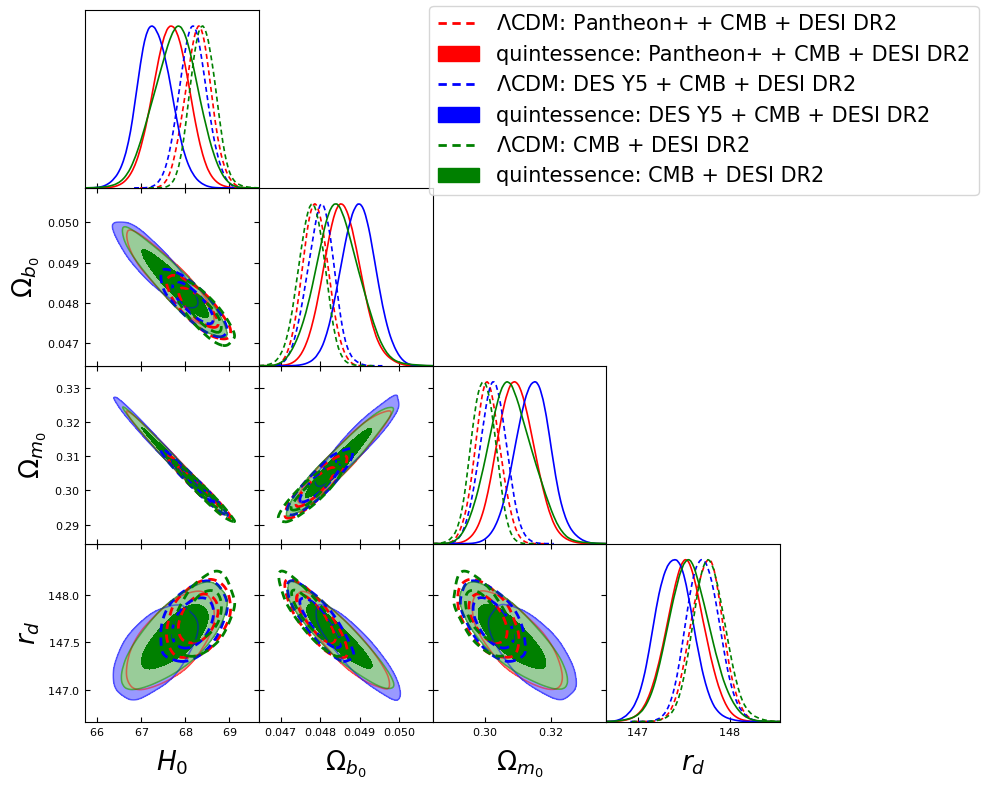

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots

# ------------------------------------------------------------
# Matplotlib tick sizes
# ------------------------------------------------------------
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
cpl_prefix    = "/Users/prasantasahoo/Documents/cobaya_project/cpl/chains/cpl/cpl_"
lcdm_prefix    = "/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_"
quintessence_prefix = "/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_"

sets = [
    "set1_PP_CMB_DESI",
    "set2_DESY5_CMB_DESI",
    "set3_CMB_DESI"
]

dataset_labels = [
    "Pantheon+ + CMB + DESI DR2",
    "DES Y5 + CMB + DESI DR2",
    "CMB + DESI DR2"
]

# ------------------------------------------------------------
# Load samples
# ------------------------------------------------------------
samples = []
legend_labels = []
line_args = []
contour_colors = []
filled_list = []
ls_list = []

colors = ["red", "blue", "green"]

for s, label, col in zip(sets, dataset_labels, colors):

    # # cpl: Unfilled, dotted
    # cpl = loadMCSamples(cpl_prefix + s, settings={"ignore_rows": 0.3})
    # samples.append(cpl)
    # legend_labels.append(r"CPL: " + label)
    # line_args.append({"ls": ":", "lw": 2, "color": col})
    # contour_colors.append(col)
    # filled_list.append(False)
    # ls_list.append(":")

    # ΛCDM: Unfilled, dotted
    lcdm = loadMCSamples(lcdm_prefix + s, settings={"ignore_rows": 0.3})
    samples.append(lcdm)
    legend_labels.append(r"$\Lambda$CDM: " + label)
    line_args.append({"ls": "--", "lw": 2, "color": col})
    contour_colors.append(col)
    filled_list.append(False)
    ls_list.append("--")

    # quintessence: Filled, solid
    quintessence = loadMCSamples(quintessence_prefix + s, settings={"ignore_rows": 0.3})
    samples.append(quintessence)
    legend_labels.append("quintessence: " + label)
    line_args.append({"ls": "-", "lw": 2, "color": col})
    contour_colors.append(col)
    filled_list.append(True)
    ls_list.append("-")

# ------------------------------------------------------------
# SAFE PARAMETER LABEL MODIFICATION (IN-PLACE)
# ------------------------------------------------------------
latex_labels = {
    "H0": r"H_{0}",
    "Omegab0": r"\Omega_{b_0}",
    "Omegam0": r"\Omega_{m_0}",
    "rd": r"r_{d}"
}

for s in samples:
    for p in s.paramNames.names:
        if p.name in latex_labels:
            p.label = latex_labels[p.name]

# ------------------------------------------------------------
# Parameters (internal names ONLY)
# ------------------------------------------------------------
params = ["H0", "Omegab0", "Omegam0", "rd"]

# ------------------------------------------------------------
# Create Triangle Plot
# ------------------------------------------------------------
g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 18
g.settings.axes_labelsize  = 22
g.settings.lab_fontsize    = 22
g.settings.alpha_filled_add = 1.0

# 2D contour line width
g.settings.lw_contour = 1.2

# Legend position
g.settings.legend_loc = "upper left"

g.triangle_plot(
    samples,
    params,
    filled=filled_list,
    legend_labels=legend_labels,
    contour_colors=contour_colors,
    line_args=line_args,
    contour_ls=ls_list,
    contour_lws=[2.0] * len(samples)
)

# ------------------------------------------------------------
# Adjust 1D marginal line widths
# ------------------------------------------------------------
fig = plt.gcf()

for ax in fig.axes:
    if ax.get_xlim() == ax.get_ylim():
        continue
    for line in ax.get_lines():
        line.set_linewidth(1.2)

# ------------------------------------------------------------
# Legend shift (Matplotlib-safe)
# ------------------------------------------------------------
leg = fig.legends[0] if fig.legends else None
if leg is not None:
    leg.set_bbox_to_anchor((0.88, 0.98))

# ------------------------------------------------------------
# Save & show
# ------------------------------------------------------------
plt.savefig(
    "lcdm_dotted_vs_quintessence_filled.pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()